# Phase 2 — Corruption Process & BasicUNet

This notebook exercises the `dms` package built in Phase 2 of the project:

- `dms.corrupt.corrupt` — the toy linear noising process
- `dms.models.BasicUNet` — the minimal from-scratch UNet
- `dms.data` — dataset loading helpers (MNIST / FashionMNIST)

It mirrors the relevant sections of the original course notebook
([Diffusion Models from Scratch](https://huggingface.co/learn/diffusion-course/en/unit1/3)),
but calls into the reusable, tested package instead of redefining everything inline.

**Note on data:** downloading real MNIST/FashionMNIST requires network access to the
torchvision dataset mirrors. If you're running this somewhere without that access, swap
`get_dataloader("mnist")` below for `torchvision.datasets.FakeData(...)`, as done to
generate `docs/assets/corruption_sweep.png` for this repo — it produces correctly-shaped
random images so you can sanity-check the pipeline without a real download.

In [1]:
import torch
import torchvision
from matplotlib import pyplot as plt

from dms.corrupt import corrupt
from dms.models import BasicUNet, count_parameters
from dms.data import get_dataloader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## The data

Uses real MNIST if you have network access; falls back to `FakeData` otherwise so the rest of the notebook still runs.

Falling back to FakeData (real MNIST unavailable: Error downloading train-images-idx3-ubyte.gz:
Tried https://ossci-datasets.s3.amazonaws.com/mnist/, got:
HTTP Error 403: Forbidden
Tried http://yann.lecun.com/exdb/mnist/, got:
HTTP Error 403: Forbidden
)


Input shape: torch.Size([8, 1, 28, 28])


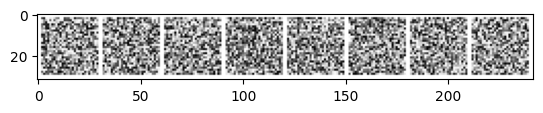

In [2]:
try:
    train_dataloader = get_dataloader(name="mnist", root="data", batch_size=8, download=True)
    x, y = next(iter(train_dataloader))
except Exception as e:
    print(f"Falling back to FakeData (real MNIST unavailable: {e})")
    fake_dataset = torchvision.datasets.FakeData(
        size=64, image_size=(1, 28, 28), num_classes=10,
        transform=torchvision.transforms.ToTensor(),
    )
    train_dataloader = torch.utils.data.DataLoader(fake_dataset, batch_size=8, shuffle=True)
    x, y = next(iter(train_dataloader))

print("Input shape:", x.shape)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap="Greys");

## The corruption process

Sweep `amount` from 0 to 1 across the batch and visualize the effect of `corrupt`.

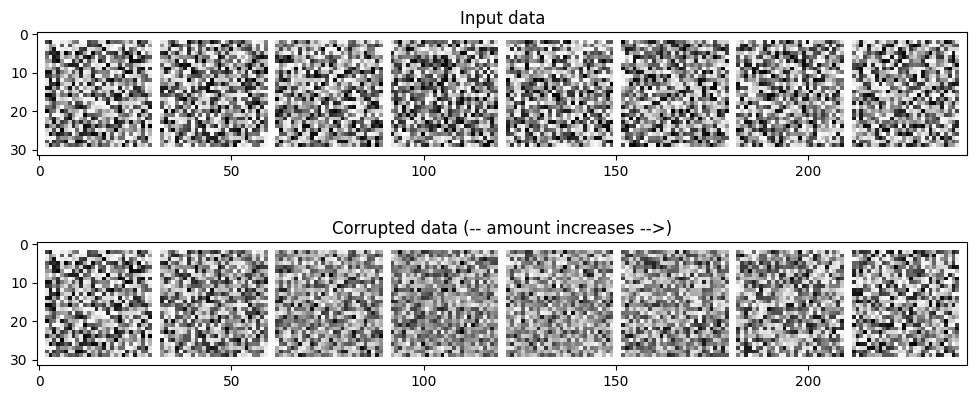

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")

amount = torch.linspace(0, 1, x.shape[0])
noised_x = corrupt(x, amount)

axs[1].set_title("Corrupted data (-- amount increases -->)")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap="Greys");

## The model

`BasicUNet`: three down-conv layers, three up-conv layers, skip connections, `MaxPool2d`/`Upsample` for resizing.

In [4]:
net = BasicUNet()
out = net(x)
print("Output shape:", out.shape)
print("Parameter count:", count_parameters(net))  # Notebook reports "just over 300,000"

Output shape: torch.Size([8, 1, 28, 28])
Parameter count: 309057


## Next steps

This notebook only exercises Phase 2 (data, corruption, model shapes). Training the
model and sampling from it are covered in `02_training_and_sampling.ipynb`, added in
Phase 3. Comparing this toy setup against a `diffusers`-based DDPM implementation is
Phase 4 (`03_ddpm_comparison.ipynb`).